<font color="purple" size=5><center><b>Task-1 Credit-Scoring-Model </b></center></font>

<font color="grey" size=5>**1) Importing Library's**</font>

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.impute import SimpleImputer
import joblib
from pathlib import Path

df = pd.read_csv('GiveMeSomeCredit/cs-training.csv').drop(['Unnamed: 0'], axis=1)


<font color="grey" size=5>**2) Feature Engineering and Spliting the Dataset into training and testing Dataset**</font>

In [20]:
# Feature Engineering: Handling missing values [cite: 31]
imputer = SimpleImputer(strategy='median')
df_filled = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Define Features and Target [cite: 28, 31]
X = df_filled.drop('SeriousDlqin2yrs', axis=1)
y = df_filled['SeriousDlqin2yrs']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<font color="grey" size=5>**3) Model Training and Testing**</font>

In [57]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}
results = {}
confusion_matrices = {}
roc_data = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }
    confusion_matrices[name] = confusion_matrix(y_test, preds)
    roc_data[name] = roc_curve(y_test, probs)
    precision_r, recall_r, thresholds_r = precision_recall_curve(y_test, probs)
results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression    0.9389   0.607706  0.177403  0.274634  0.692690
Decision Tree          0.9389   0.607706  0.177403  0.274634  0.821057
Random Forest          0.9389   0.607706  0.177403  0.274634  0.862039


<font color="grey" size=5>**4) Model Visulazation**</font>

<font color="grey" size=5>**a) Bar Graph**</font>

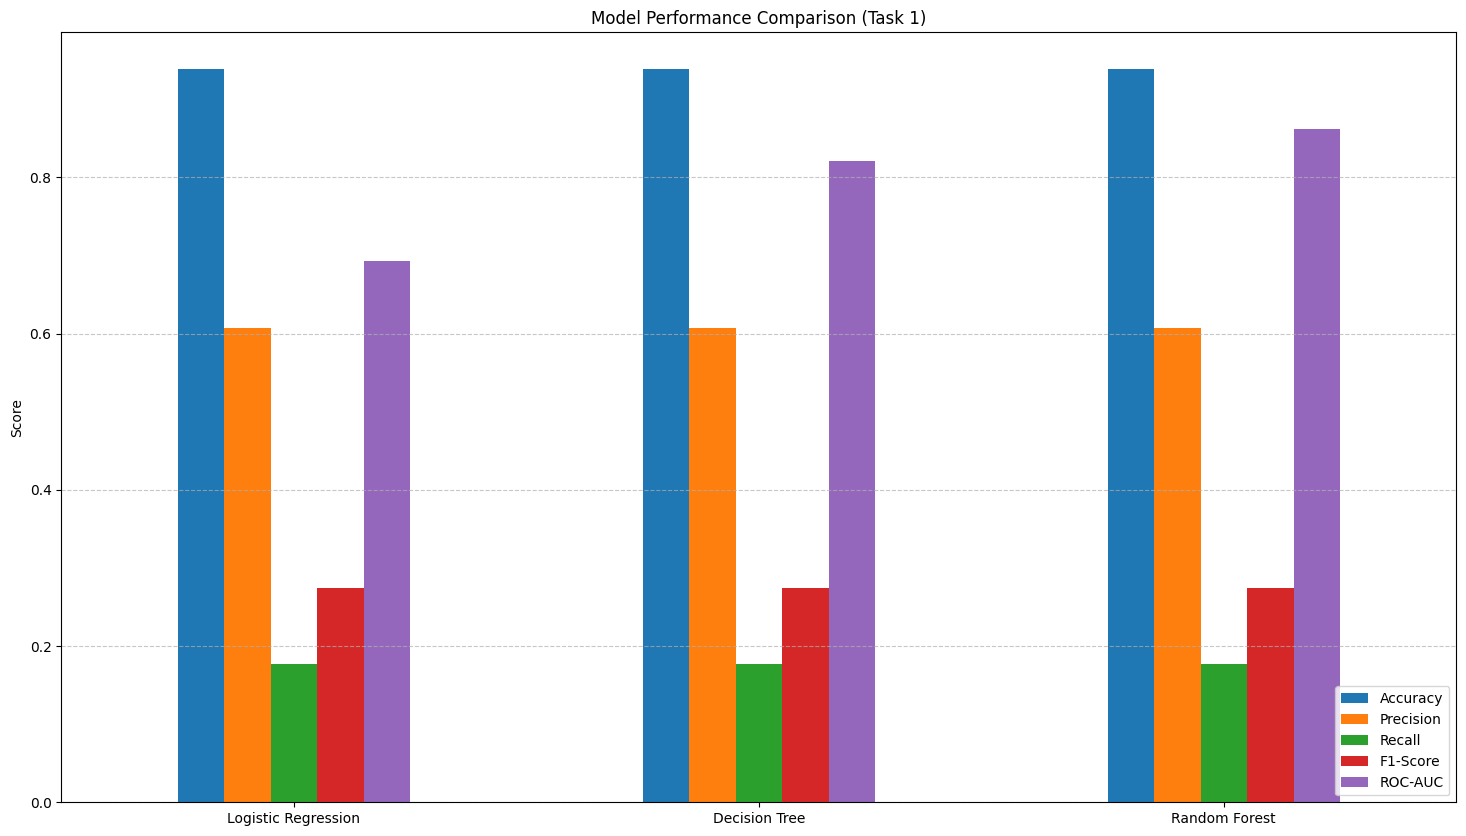

In [73]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df = pd.DataFrame(results, index=metrics_names).T
results_df.plot(kind='bar', figsize=(18, 10))
plt.title('Model Performance Comparison (Task 1)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<font color="grey" size=5>**b) Heat Map**</font>

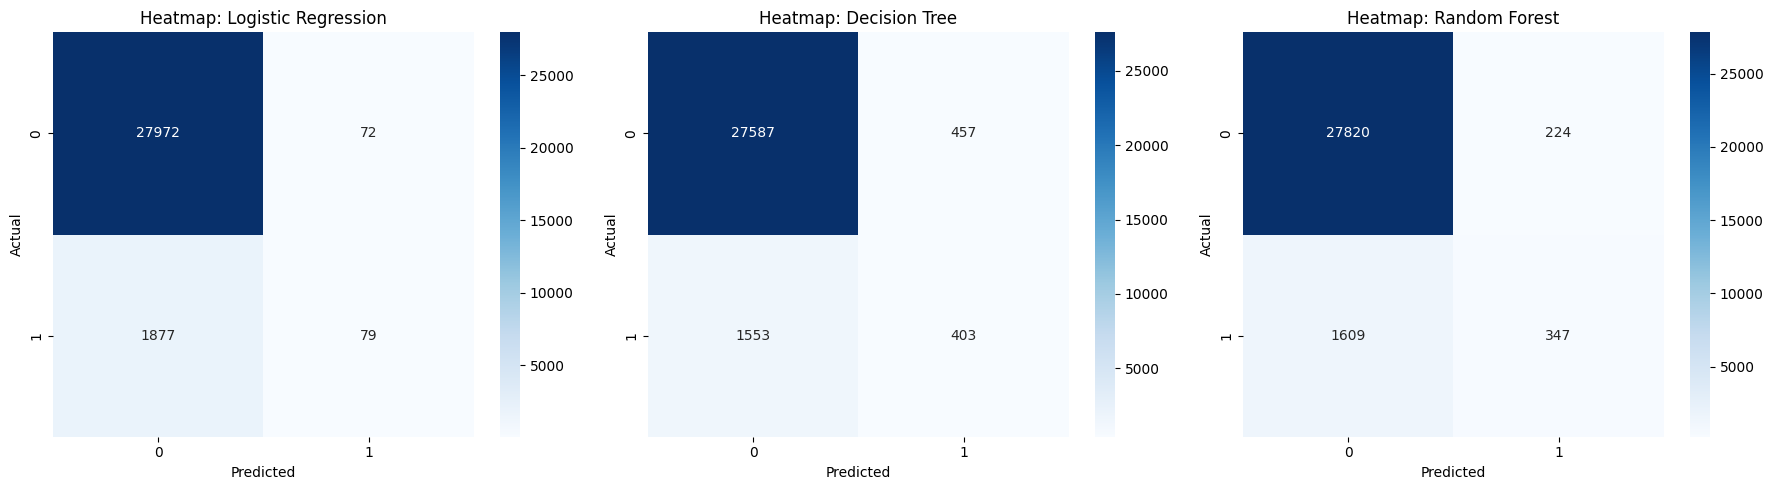

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Heatmap: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()


<font color="grey" size=5>**c) Line Chart for ROC-AUC curve**</font>

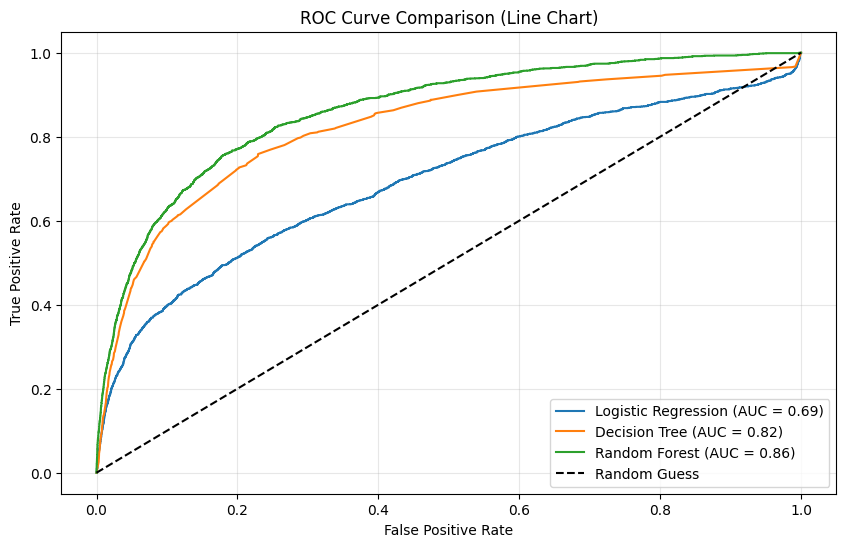

In [61]:
plt.figure(figsize=(10, 6))
for name, (fpr, tpr, thresholds) in roc_data.items():
    auc = results[name]["ROC-AUC"]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison (Line Chart)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<font color="grey" size=5>**d) Line Chart for Precision,Recall and F1-Score Vs Threshold**</font>

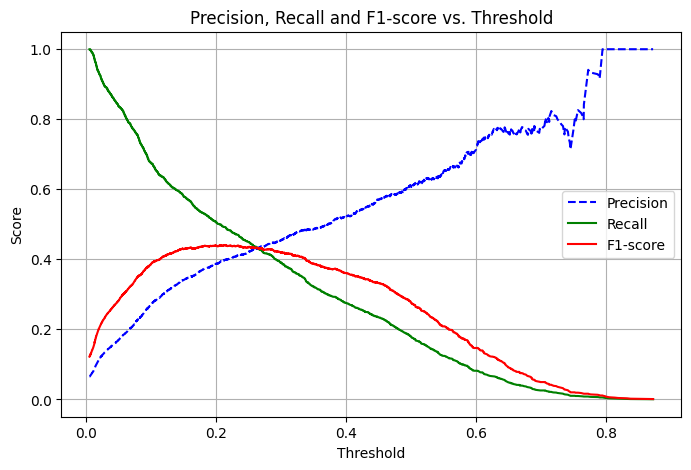

In [62]:
f1_scores_r = 2 * (precision * recall) / (precision + recall)
plt.figure(figsize=(8, 5))
plt.plot(thresholds_r, precision_r[:-1], 'b--', label='Precision')
plt.plot(thresholds_r, recall_r[:-1], 'g-', label='Recall')
plt.plot(thresholds_r, f1_scores_r[:-1], 'r-', label='F1-score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1-score vs. Threshold')
plt.legend(loc='best')
plt.grid(True)
plt.show()

<font color="grey" size=5>**5) Deployment**</font>

In [85]:
best_model_name = results_df['Accuracy'].idxmax()
print(f"\n--- Deployment Choice: {best_model_name} ---")
best_model = models[best_model_name]
output_path = Path("pkl")
output_path.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, output_path / 'credit_scoring_model.pkl')
print(f"Model saved as 'credit_scoring_model.pkl' with {results_df.loc[best_model_name, 'Accuracy']*100:.2f}% accuracy.")


--- Deployment Choice: Logistic Regression ---
Model saved as 'credit_scoring_model.pkl' with 93.89% accuracy.
